# Google Cloud CMIP6 Public Data: Basic Python Example

This notebooks shows how to query the catalog and load the data using python

In [1]:
! pip3 install --upgrade xarray zarr gcsfs cftime nc-time-axis

  Obtaining dependency information for numpy>=1.26 from https://files.pythonhosted.org/packages/8a/dc/df98c095978fa6ee7b9a9387d1d58cbb3d232d0e69ad169a4ce784bde4fd/numpy-2.4.4-cp311-cp311-macosx_14_0_arm64.whl.metadata
  Using cached numpy-2.4.4-cp311-cp311-macosx_14_0_arm64.whl.metadata (6.6 kB)
Using cached numpy-2.4.4-cp311-cp311-macosx_14_0_arm64.whl (5.5 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4

[notice] A new release of pip is available: 23.2.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [2]:
! pip3 install "numpy==1.26.4"
! pip3 install --upgrade numexpr bottleneck

  Obtaining dependency information for numpy==1.26.4 from https://files.pythonhosted.org/packages/1a/2e/151484f49fd03944c4a3ad9c418ed193cfd02724e138ac8a9505d056c582/numpy-1.26.4-cp311-cp311-macosx_11_0_arm64.whl.metadata
  Using cached numpy-1.26.4-cp311-cp311-macosx_11_0_arm64.whl.metadata (114 kB)
Using cached numpy-1.26.4-cp311-cp311-macosx_11_0_arm64.whl (14.0 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.4
    Uninstalling numpy-2.4.4:
      Successfully uninstalled numpy-2.4.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
zarr 3.1.6 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.

[notice] A new release of pip is available: 23.2.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 23.2.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

In [3]:
!/Applications/Python\ 3.14/Install\ Certificates.command

zsh:1: no such file or directory: /Applications/Python 3.14/Install Certificates.command


In [4]:
from matplotlib import pyplot as plt
import numpy as np
import ssl
ssl._create_default_https_context = ssl._create_unverified_context
import pandas as pd

# Now this will work
df = pd.read_csv('https://storage.googleapis.com/cmip6/cmip6-zarr-consolidated-stores.csv')
df.head()
import pandas as pd
import xarray as xr
import zarr
import gcsfs

xr.set_options(display_style='html')
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [5]:
plt.rcParams['figure.figsize'] = 12, 6

## Browse Catalog

The data catatalog is stored as a CSV file. Here we read it with Pandas.

In [6]:
df = pd.read_csv('https://storage.googleapis.com/cmip6/cmip6-zarr-consolidated-stores.csv')
df.head()

,activity_id,institution_id,source_id,experiment_id,member_id,table_id,variable_id,grid_label,zstore,dcpp_init_year,version
0,HighResMIP,CMCC,CMCC-CM2-HR4,highresSST-present,r1i1p1f1,Amon,ps,gn,gs://cmip6/CMIP6/HighResMIP/CMCC/CMCC-CM2-HR4/...,NaN,20170706
1,HighResMIP,CMCC,CMCC-CM2-HR4,highresSST-present,r1i1p1f1,Amon,rsds,gn,gs://cmip6/CMIP6/HighResMIP/CMCC/CMCC-CM2-HR4/...,NaN,20170706
2,HighResMIP,CMCC,CMCC-CM2-HR4,highresSST-present,r1i1p1f1,Amon,rlus,gn,gs://cmip6/CMIP6/HighResMIP/CMCC/CMCC-CM2-HR4/...,NaN,20170706
3,HighResMIP,CMCC,CMCC-CM2-HR4,highresSST-present,r1i1p1f1,Amon,rlds,gn,gs://cmip6/CMIP6/HighResMIP/CMCC/CMCC-CM2-HR4/...,NaN,20170706
4,HighResMIP,CMCC,CMCC-CM2-HR4,highresSST-present,r1i1p1f1,Amon,psl,gn,gs://cmip6/CMIP6/HighResMIP/CMCC/CMCC-CM2-HR4/...,NaN,20170706


The columns of the dataframe correspond to the CMI6 controlled vocabulary. A beginners' guide to these terms is available in [this document](https://docs.google.com/document/d/1yUx6jr9EdedCOLd--CPdTfGDwEwzPpCF6p1jRmqx-0Q).

Here we filter the data to find monthly surface air temperature for historical experiments.

In [7]:
df_ta = df.query("activity_id=='CMIP' & table_id == 'Amon' & variable_id == 'tas' & experiment_id == 'historical'")
df_ta

,activity_id,institution_id,source_id,experiment_id,member_id,table_id,variable_id,grid_label,zstore,dcpp_init_year,version
973,CMIP,NOAA-GFDL,GFDL-ESM4,historical,r3i1p1f1,Amon,tas,gr1,gs://cmip6/CMIP6/CMIP/NOAA-GFDL/GFDL-ESM4/hist...,NaN,20180701
1766,CMIP,NOAA-GFDL,GFDL-ESM4,historical,r2i1p1f1,Amon,tas,gr1,gs://cmip6/CMIP6/CMIP/NOAA-GFDL/GFDL-ESM4/hist...,NaN,20180701
8074,CMIP,NOAA-GFDL,GFDL-CM4,historical,r1i1p1f1,Amon,tas,gr1,gs://cmip6/CMIP6/CMIP/NOAA-GFDL/GFDL-CM4/histo...,NaN,20180701
22185,CMIP,IPSL,IPSL-CM6A-LR,historical,r8i1p1f1,Amon,tas,gr,gs://cmip6/CMIP6/CMIP/IPSL/IPSL-CM6A-LR/histor...,NaN,20180803
22298,CMIP,IPSL,IPSL-CM6A-LR,historical,r2i1p1f1,Amon,tas,gr,gs://cmip6/CMIP6/CMIP/IPSL/IPSL-CM6A-LR/histor...,NaN,20180803
...,...,...,...,...,...,...,...,...,...,...,...
522952,CMIP,MRI,MRI-ESM2-0,historical,r7i1p1f1,Amon,tas,gn,gs://cmip6/CMIP6/CMIP/MRI/MRI-ESM2-0/historica...,NaN,20210813
523274,CMIP,MRI,MRI-ESM2-0,historical,r6i1p1f1,Amon,tas,gn,gs://cmip6/CMIP6/CMIP/MRI/MRI-ESM2-0/historica...,NaN,20210907
523712,CMIP,CMCC,CMCC-CM2-SR5,historical,r3i1p2f1,Amon,tas,gn,gs://cmip6/CMIP6/CMIP/CMCC/CMCC-CM2-SR5/histor...,NaN,20211108
523721,CMIP,CMCC,CMCC-CM2-SR5,historical,r2i1p2f1,Amon,tas,gn,gs://cmip6/CMIP6/CMIP/CMCC/CMCC-CM2-SR5/histor...,NaN,20211109


Now we do further filtering to find just the models from NCAR.

In [8]:
df_ta_ncar = df_ta.query('institution_id == "NCAR"')
df_ta_ncar

,activity_id,institution_id,source_id,experiment_id,member_id,table_id,variable_id,grid_label,zstore,dcpp_init_year,version
56049,CMIP,NCAR,CESM2-WACCM,historical,r2i1p1f1,Amon,tas,gn,gs://cmip6/CMIP6/CMIP/NCAR/CESM2-WACCM/histori...,NaN,20190227
56143,CMIP,NCAR,CESM2-WACCM,historical,r3i1p1f1,Amon,tas,gn,gs://cmip6/CMIP6/CMIP/NCAR/CESM2-WACCM/histori...,NaN,20190227
56326,CMIP,NCAR,CESM2-WACCM,historical,r1i1p1f1,Amon,tas,gn,gs://cmip6/CMIP6/CMIP/NCAR/CESM2-WACCM/histori...,NaN,20190227
59875,CMIP,NCAR,CESM2,historical,r1i1p1f1,Amon,tas,gn,gs://cmip6/CMIP6/CMIP/NCAR/CESM2/historical/r1...,NaN,20190308
61655,CMIP,NCAR,CESM2,historical,r4i1p1f1,Amon,tas,gn,gs://cmip6/CMIP6/CMIP/NCAR/CESM2/historical/r4...,NaN,20190308
61862,CMIP,NCAR,CESM2,historical,r5i1p1f1,Amon,tas,gn,gs://cmip6/CMIP6/CMIP/NCAR/CESM2/historical/r5...,NaN,20190308
62691,CMIP,NCAR,CESM2,historical,r2i1p1f1,Amon,tas,gn,gs://cmip6/CMIP6/CMIP/NCAR/CESM2/historical/r2...,NaN,20190308
63131,CMIP,NCAR,CESM2,historical,r3i1p1f1,Amon,tas,gn,gs://cmip6/CMIP6/CMIP/NCAR/CESM2/historical/r3...,NaN,20190308
63266,CMIP,NCAR,CESM2,historical,r6i1p1f1,Amon,tas,gn,gs://cmip6/CMIP6/CMIP/NCAR/CESM2/historical/r6...,NaN,20190308
64615,CMIP,NCAR,CESM2,historical,r8i1p1f1,Amon,tas,gn,gs://cmip6/CMIP6/CMIP/NCAR/CESM2/historical/r8...,NaN,20190311


## Load Data

Now we will load a single store using gcsfs, zarr, and xarray.

In [9]:
# this only needs to be created once
gcs = gcsfs.GCSFileSystem(token='anon')

# get the path to a specific zarr store (the first one from the dataframe above)
zstore = df_ta_ncar.loc[59875].zstore

# create a mutable-mapping-style interface to the store
mapper = gcs.get_mapper(zstore)

# open it using xarray and zarr
ds = xr.open_zarr(mapper, consolidated=True)
ds

I0505 22:16:04.829955 33399873 fork_posix.cc:71] Other threads are currently calling into gRPC, skipping fork() handlers
I0505 22:16:04.857879 33399892 ev_poll_posix.cc:593] FD from fork parent still in poll list: fd(105, generation: 1)
I0505 22:16:04.857968 33399892 ev_poll_posix.cc:593] FD from fork parent still in poll list: fd(105, generation: 1)
I0505 22:16:04.857974 33399892 ev_poll_posix.cc:593] FD from fork parent still in poll list: fd(105, generation: 1)
I0505 22:16:04.857981 33399892 ev_poll_posix.cc:593] FD from fork parent still in poll list: fd(105, generation: 1)
I0505 22:16:04.857987 33399892 ev_poll_posix.cc:593] FD from fork parent still in poll list: fd(105, generation: 1)
I0505 22:16:04.857994 33399892 ev_poll_posix.cc:593] FD from fork parent still in poll list: fd(105, generation: 1)
I0505 22:16:04.858000 33399892 ev_poll_posix.cc:593] FD from fork parent still in poll list: fd(105, generation: 1)
I0505 22:16:04.858003 33399892 ev_poll_posix.cc:593] FD from fork p

<xarray.Dataset> Size: 438MB
Dimensions:    (time: 1980, lat: 192, lon: 288, nbnd: 2)
Coordinates:
  * time       (time) object 16kB 1850-01-15 12:00:00 ... 2014-12-15 12:00:00
  * lat        (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon        (lon) float64 2kB 0.0 1.25 2.5 3.75 ... 355.0 356.2 357.5 358.8
    lat_bnds   (lat, nbnd) float32 2kB ...
    lon_bnds   (lon, nbnd) float32 2kB ...
    time_bnds  (time, nbnd) object 32kB ...
Dimensions without coordinates: nbnd
Data variables:
    tas        (time, lat, lon) float32 438MB ...
Attributes: (12/46)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            CMIP
    branch_method:          standard
    branch_time_in_child:   674885.0
    branch_time_in_parent:  219000.0
    case_id:                15
    ...                     ...
    table_id:               Amon
    tracking_id:            hdl:21.14100/d9a7225a-49c3-4470-b7ab-a8180926f839
    variable_id:            tas
    variant_info:           CMIP6 20th century experiments (1850-2014) with C...
    variant_label:          r1i1p1f1
    status:                 2019-10-25;created;by nhn2@columbia.edu

Plot a map from a specific date.

Create a timeseries of global-average surface air temperature. For this we need the area weighting factor for each gridpoint.

In [14]:
df_area = df.query("variable_id == 'areacella' & source_id == 'CESM2'")
ds_area = xr.open_zarr(gcs.get_mapper(df_area.zstore.values[0]), consolidated=True)
ds_area

<xarray.Dataset> Size: 229kB
Dimensions:    (lat: 192, lon: 288, nbnd: 2)
Coordinates:
  * lat        (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon        (lon) float64 2kB 0.0 1.25 2.5 3.75 ... 355.0 356.2 357.5 358.8
    lat_bnds   (lat, nbnd) float32 2kB ...
    lon_bnds   (lon, nbnd) float32 2kB ...
Dimensions without coordinates: nbnd
Data variables:
    areacella  (lat, lon) float32 221kB ...
Attributes: (12/45)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            CMIP
    branch_method:          no parent
    branch_time_in_child:   711385.0
    branch_time_in_parent:  0.0
    case_id:                38
    ...                     ...
    table_id:               fx
    tracking_id:            hdl:21.14100/23fa9dc3-4f8f-4943-b99b-58eb804c06f0
    variable_id:            areacella
    variant_info:           f.e21.FHIST_BGC.f09_f09_mg17.CMIP6-AMIP.001 
\n
\...
    variant_label:          r1i1p1f1
    status:                 2019-11-04;created;by nhn2@columbia.edu

In [15]:
total_area = ds_area.areacella.sum(dim=['lon', 'lat'])
ta_timeseries = (ds.tas * ds_area.areacella).sum(dim=['lon', 'lat']) / total_area
ta_timeseries

<xarray.DataArray (time: 1980)> Size: 8kB
array([285.2367 , 285.49353, 286.10147, ..., 288.3483 , 287.31396,
       286.56613], dtype=float32)
Coordinates:
  * time     (time) object 16kB 1850-01-15 12:00:00 ... 2014-12-15 12:00:00
Attributes: (12/19)
    cell_measures:  area: areacella
    time:           time
    type:           real
    cell_methods:   area: sum
    comment:        Cell areas for any grid used to report atmospheric variab...
    description:    Cell areas for any grid used to report atmospheric variab...
    ...             ...
    standard_name:  cell_area
    time_label:     None
    time_title:     No temporal dimensions ... fixed field
    title:          Grid-Cell Area for Atmospheric Grid Variables
    units:          m2
    variable_id:    areacella

In [16]:
ta_timeseries.load()

<xarray.DataArray (time: 1980)> Size: 8kB
array([285.2367 , 285.49353, 286.10147, ..., 288.3483 , 287.31396,
       286.56613], dtype=float32)
Coordinates:
  * time     (time) object 16kB 1850-01-15 12:00:00 ... 2014-12-15 12:00:00
Attributes: (12/19)
    cell_measures:  area: areacella
    time:           time
    type:           real
    cell_methods:   area: sum
    comment:        Cell areas for any grid used to report atmospheric variab...
    description:    Cell areas for any grid used to report atmospheric variab...
    ...             ...
    standard_name:  cell_area
    time_label:     None
    time_title:     No temporal dimensions ... fixed field
    title:          Grid-Cell Area for Atmospheric Grid Variables
    units:          m2
    variable_id:    areacella

In [17]:
sd_time_series = ds.tas.sel(lon=360-117.1611, lat=32.7157, method='nearest')

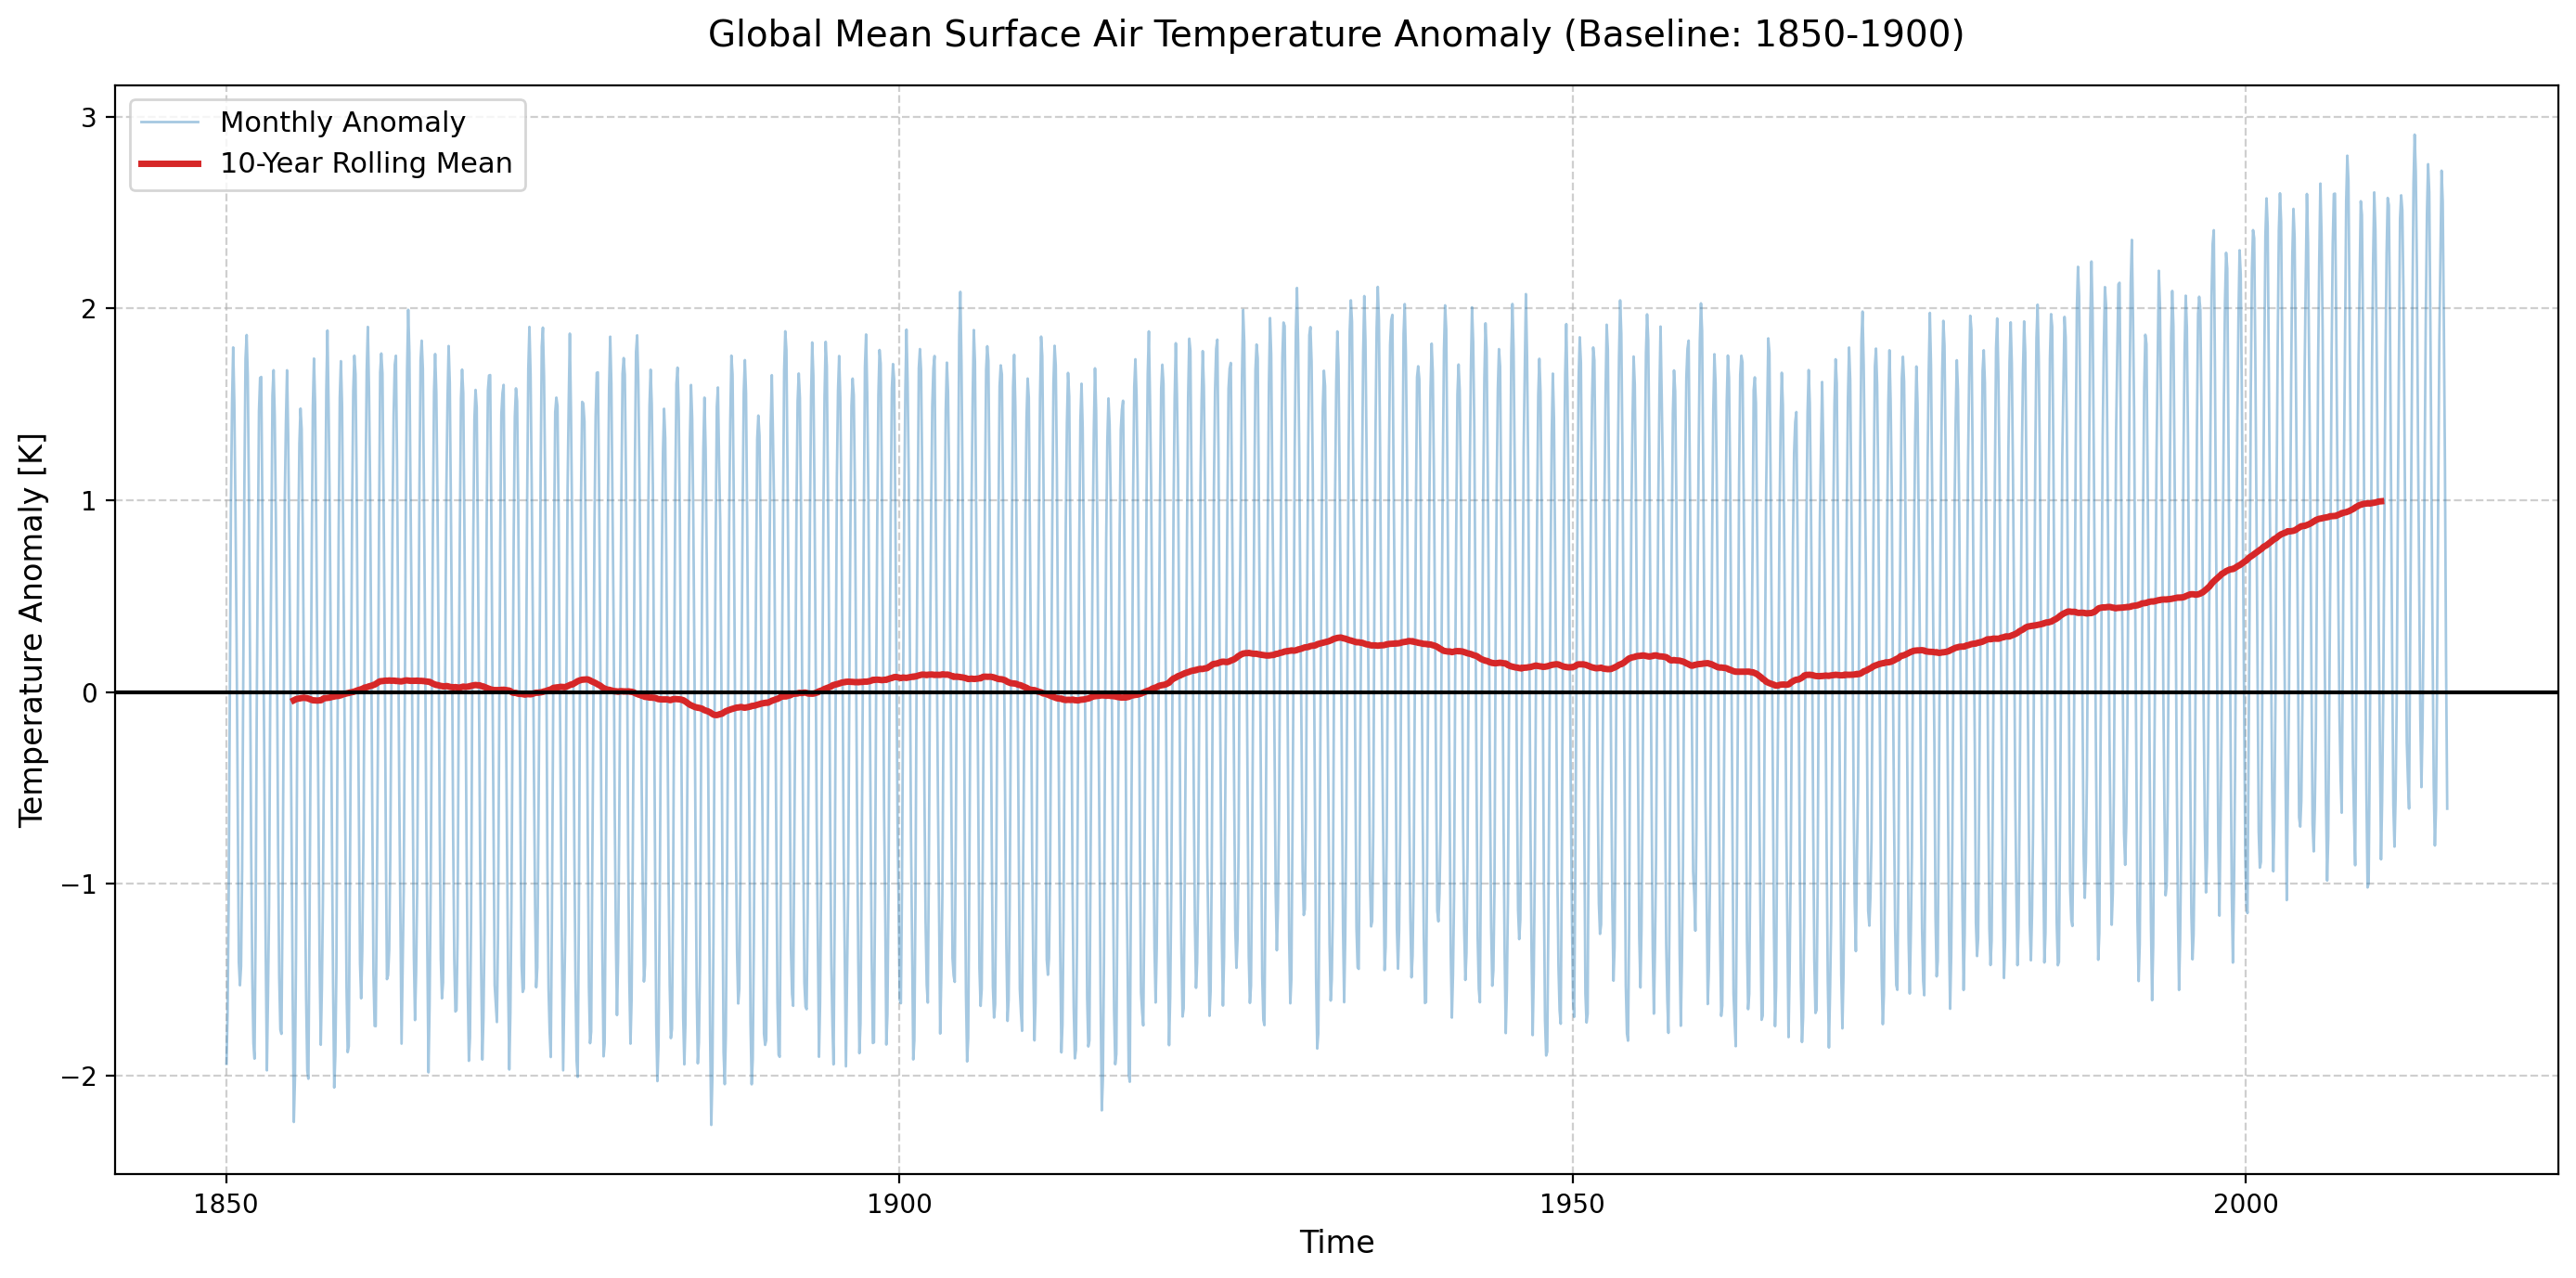

In [18]:
import matplotlib.pyplot as plt

baseline_global = ta_timeseries.sel(time=slice("1850", "1900")).mean()
global_anomaly = ta_timeseries - baseline_global

fig, ax = plt.subplots(figsize=(14, 7))

global_anomaly.plot(ax=ax, label='Monthly Anomaly', color='tab:blue', alpha=0.4, linewidth=1)
global_anomaly.rolling(time=120, center=True).mean().plot(ax=ax, label='10-Year Rolling Mean', color='tab:red', linewidth=2.5)

ax.axhline(0, color='black', linestyle='-', linewidth=1.5) # The zero-baseline
ax.set_title('Global Mean Surface Air Temperature Anomaly (Baseline: 1850-1900)', fontsize=14, pad=15)
ax.set_ylabel('Temperature Anomaly [K]', fontsize=12)
ax.set_xlabel('Time', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(loc='upper left', fontsize=11)

plt.tight_layout()
plt.show()

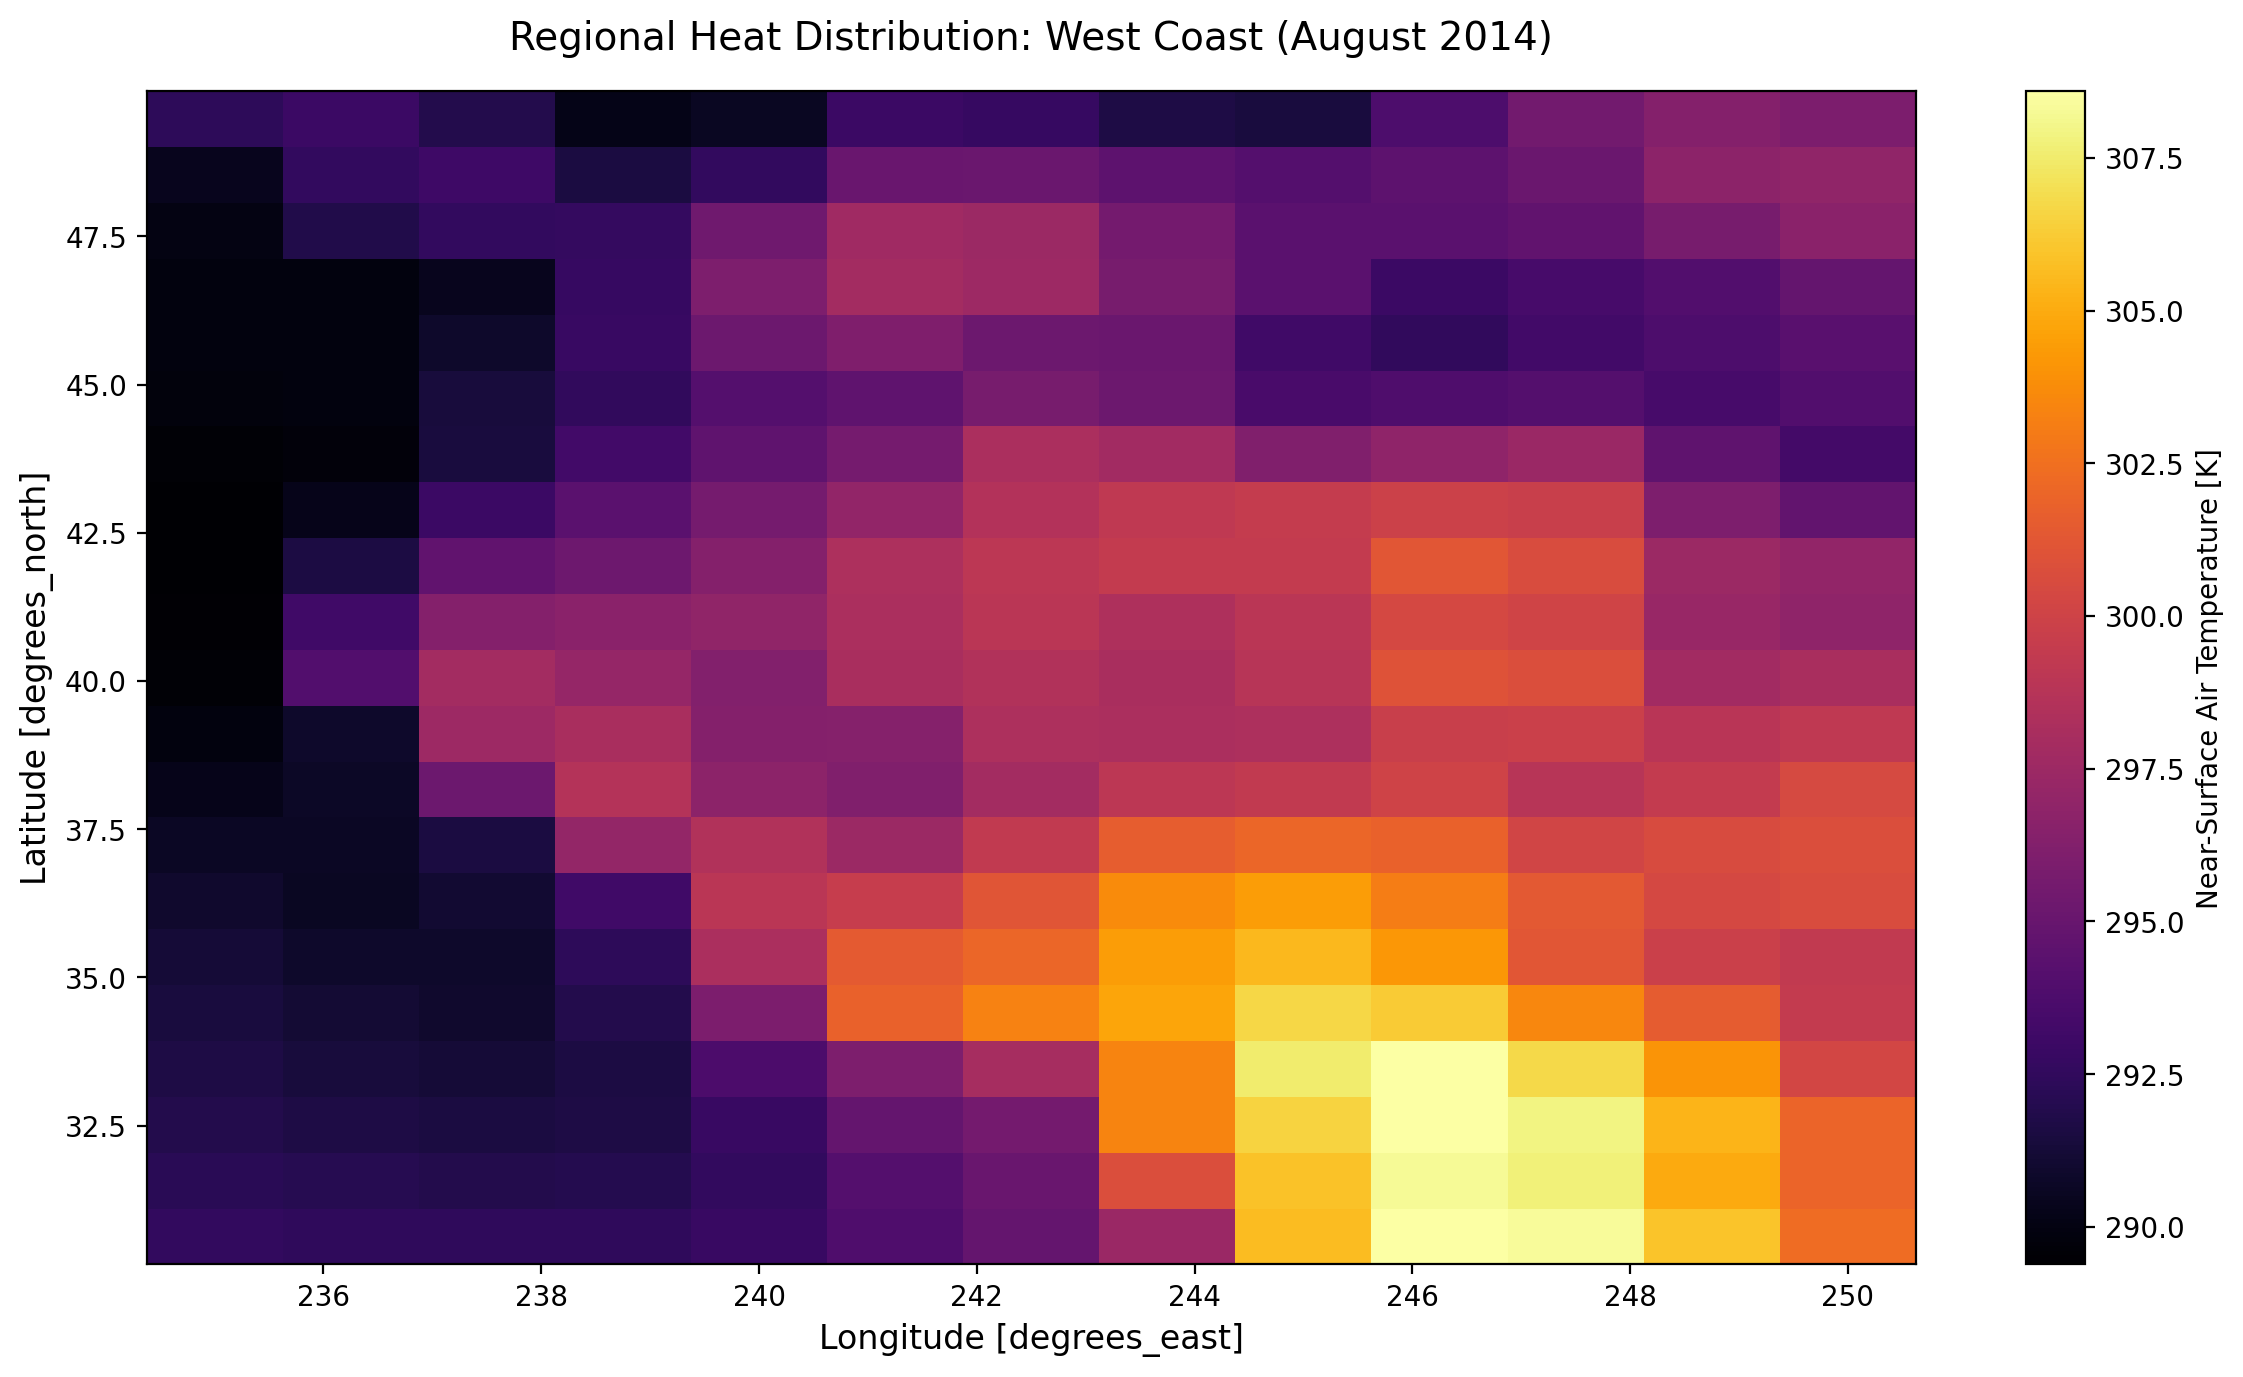

In [19]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 7))

recent_heat = ds.tas.sel(time='2014-08').squeeze()

west_coast = recent_heat.sel(lat=slice(30, 50), lon=slice(360-125, 360-110))

plot = west_coast.plot(ax=ax, cmap='inferno', add_colorbar=True, 
                       cbar_kwargs={'label': 'Near-Surface Air Temperature [K]'})

ax.set_title('Regional Heat Distribution: West Coast (August 2014)', fontsize=14, pad=15)
ax.set_xlabel('Longitude [degrees_east]', fontsize=12)
ax.set_ylabel('Latitude [degrees_north]', fontsize=12)

plt.tight_layout()
plt.show()

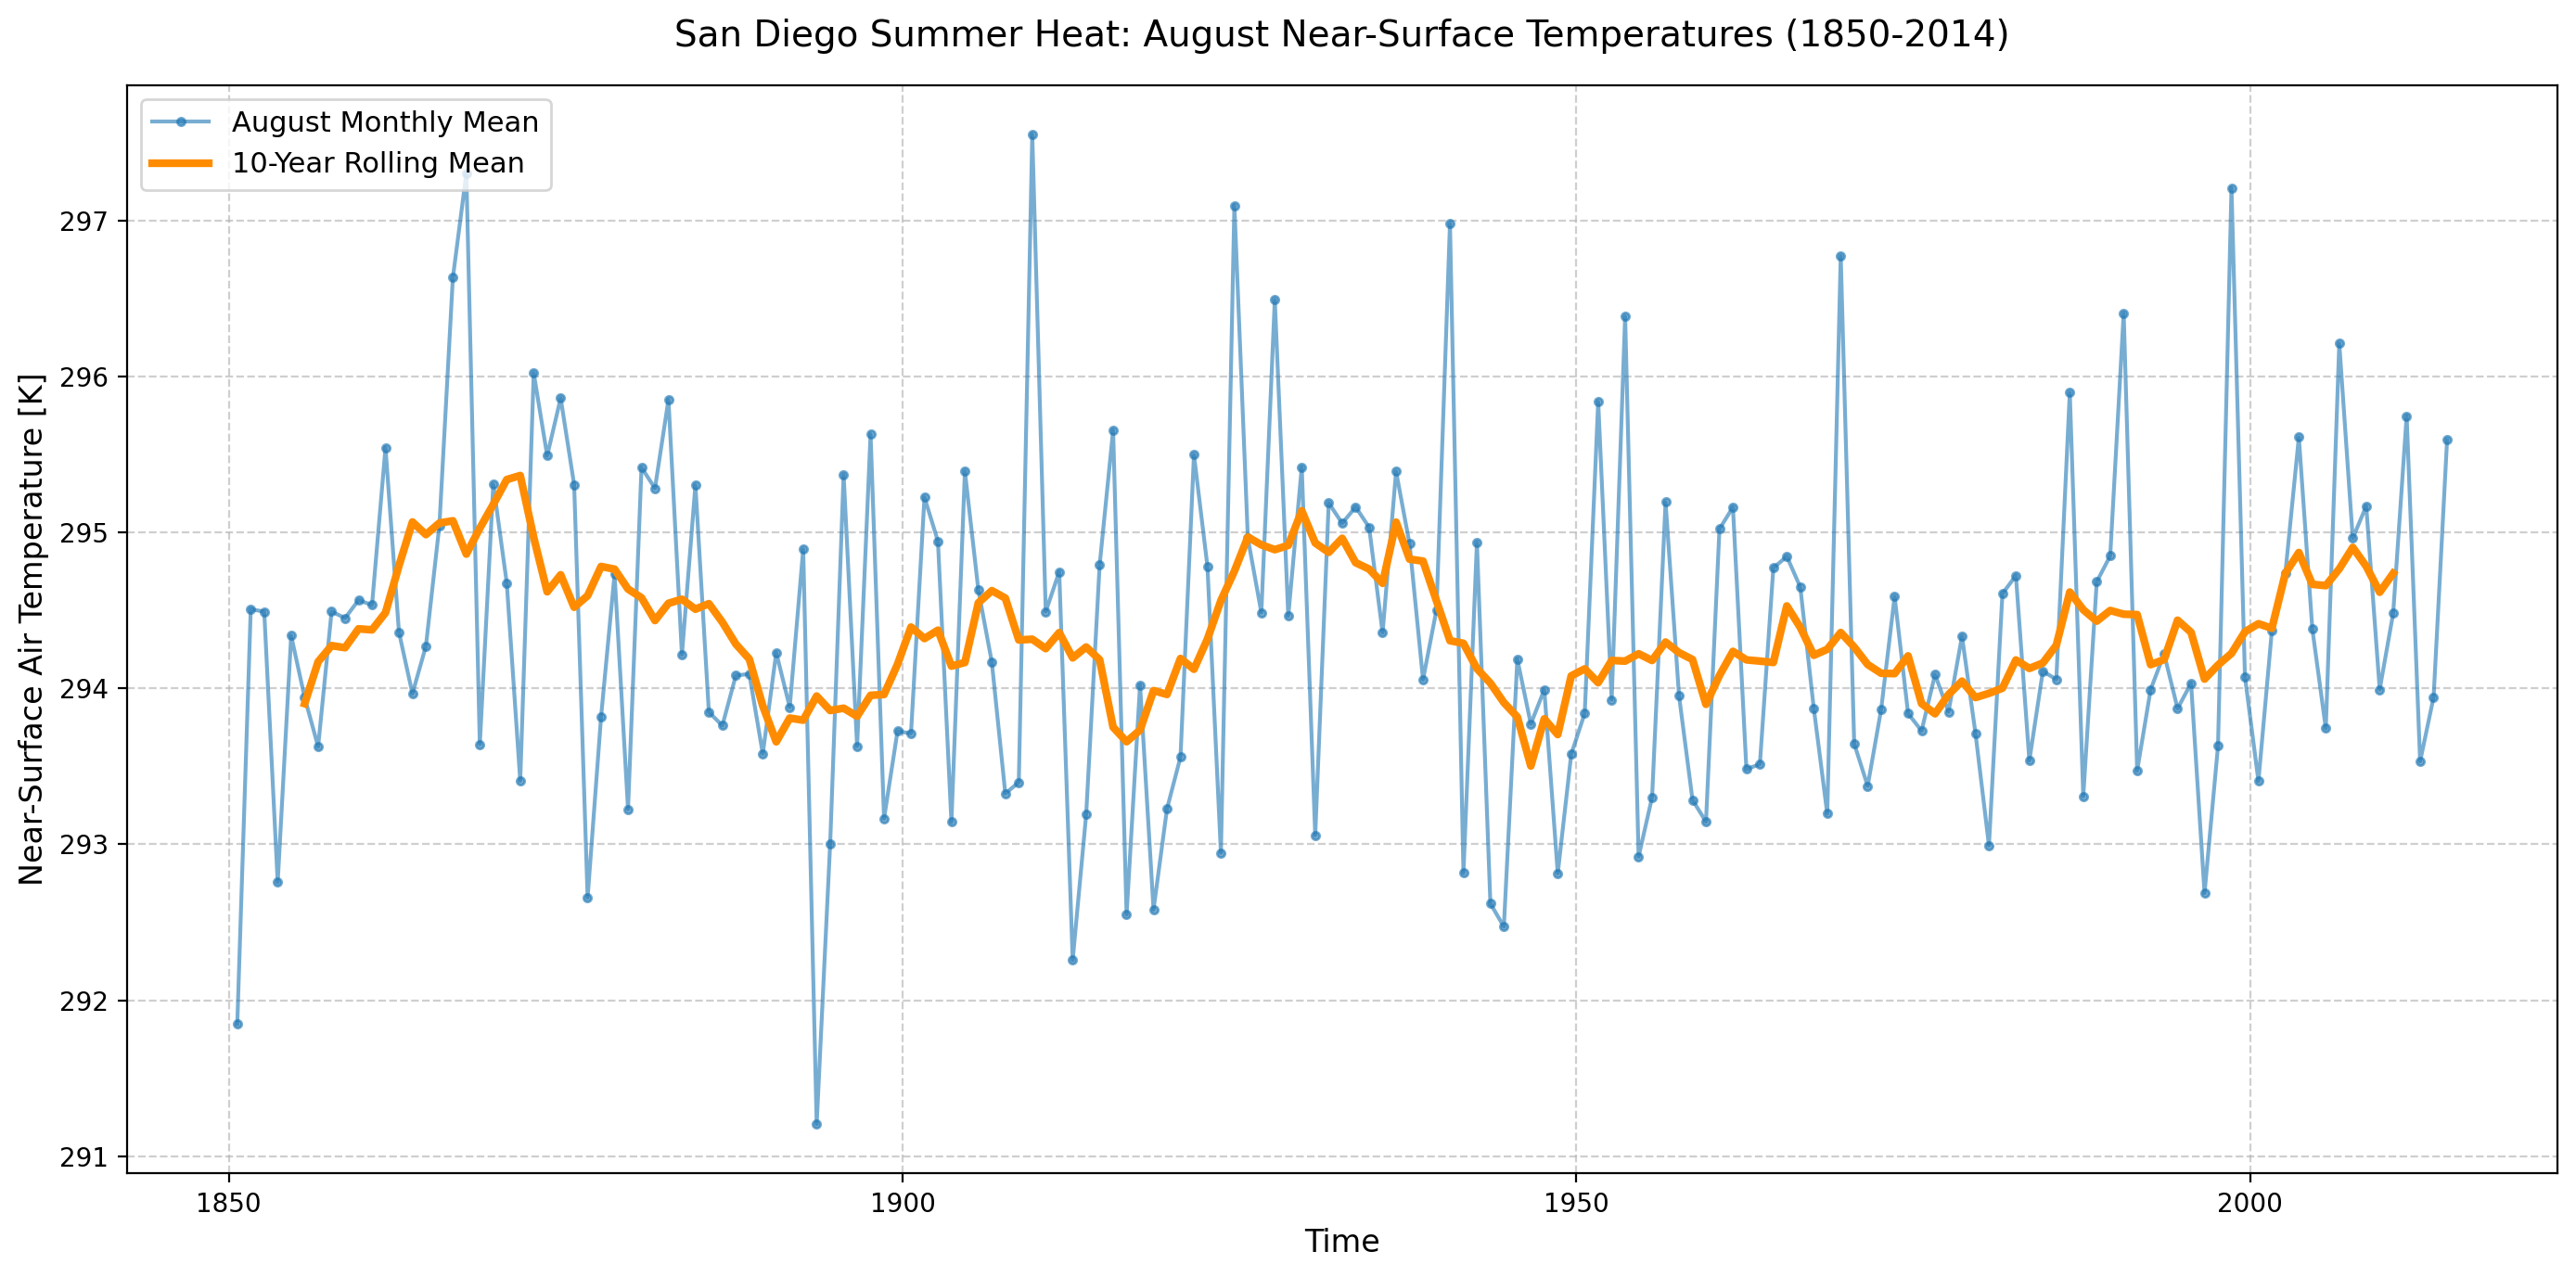

In [20]:
import matplotlib.pyplot as plt

sd_august = sd_time_series.sel(time=sd_time_series['time.month'] == 8)

fig, ax = plt.subplots(figsize=(14, 7))

sd_august.plot(ax=ax, label='August Monthly Mean', color='tab:blue', alpha=0.6, marker='.', linestyle='-')
sd_august.rolling(time=10, center=True).mean().plot(ax=ax, label='10-Year Rolling Mean', color='darkorange', linewidth=3)

ax.set_title('San Diego Summer Heat: August Near-Surface Temperatures (1850-2014)', fontsize=14, pad=15)
ax.set_ylabel('Near-Surface Air Temperature [K]', fontsize=12)
ax.set_xlabel('Time', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(loc='upper left', fontsize=11)

plt.tight_layout()
plt.show()

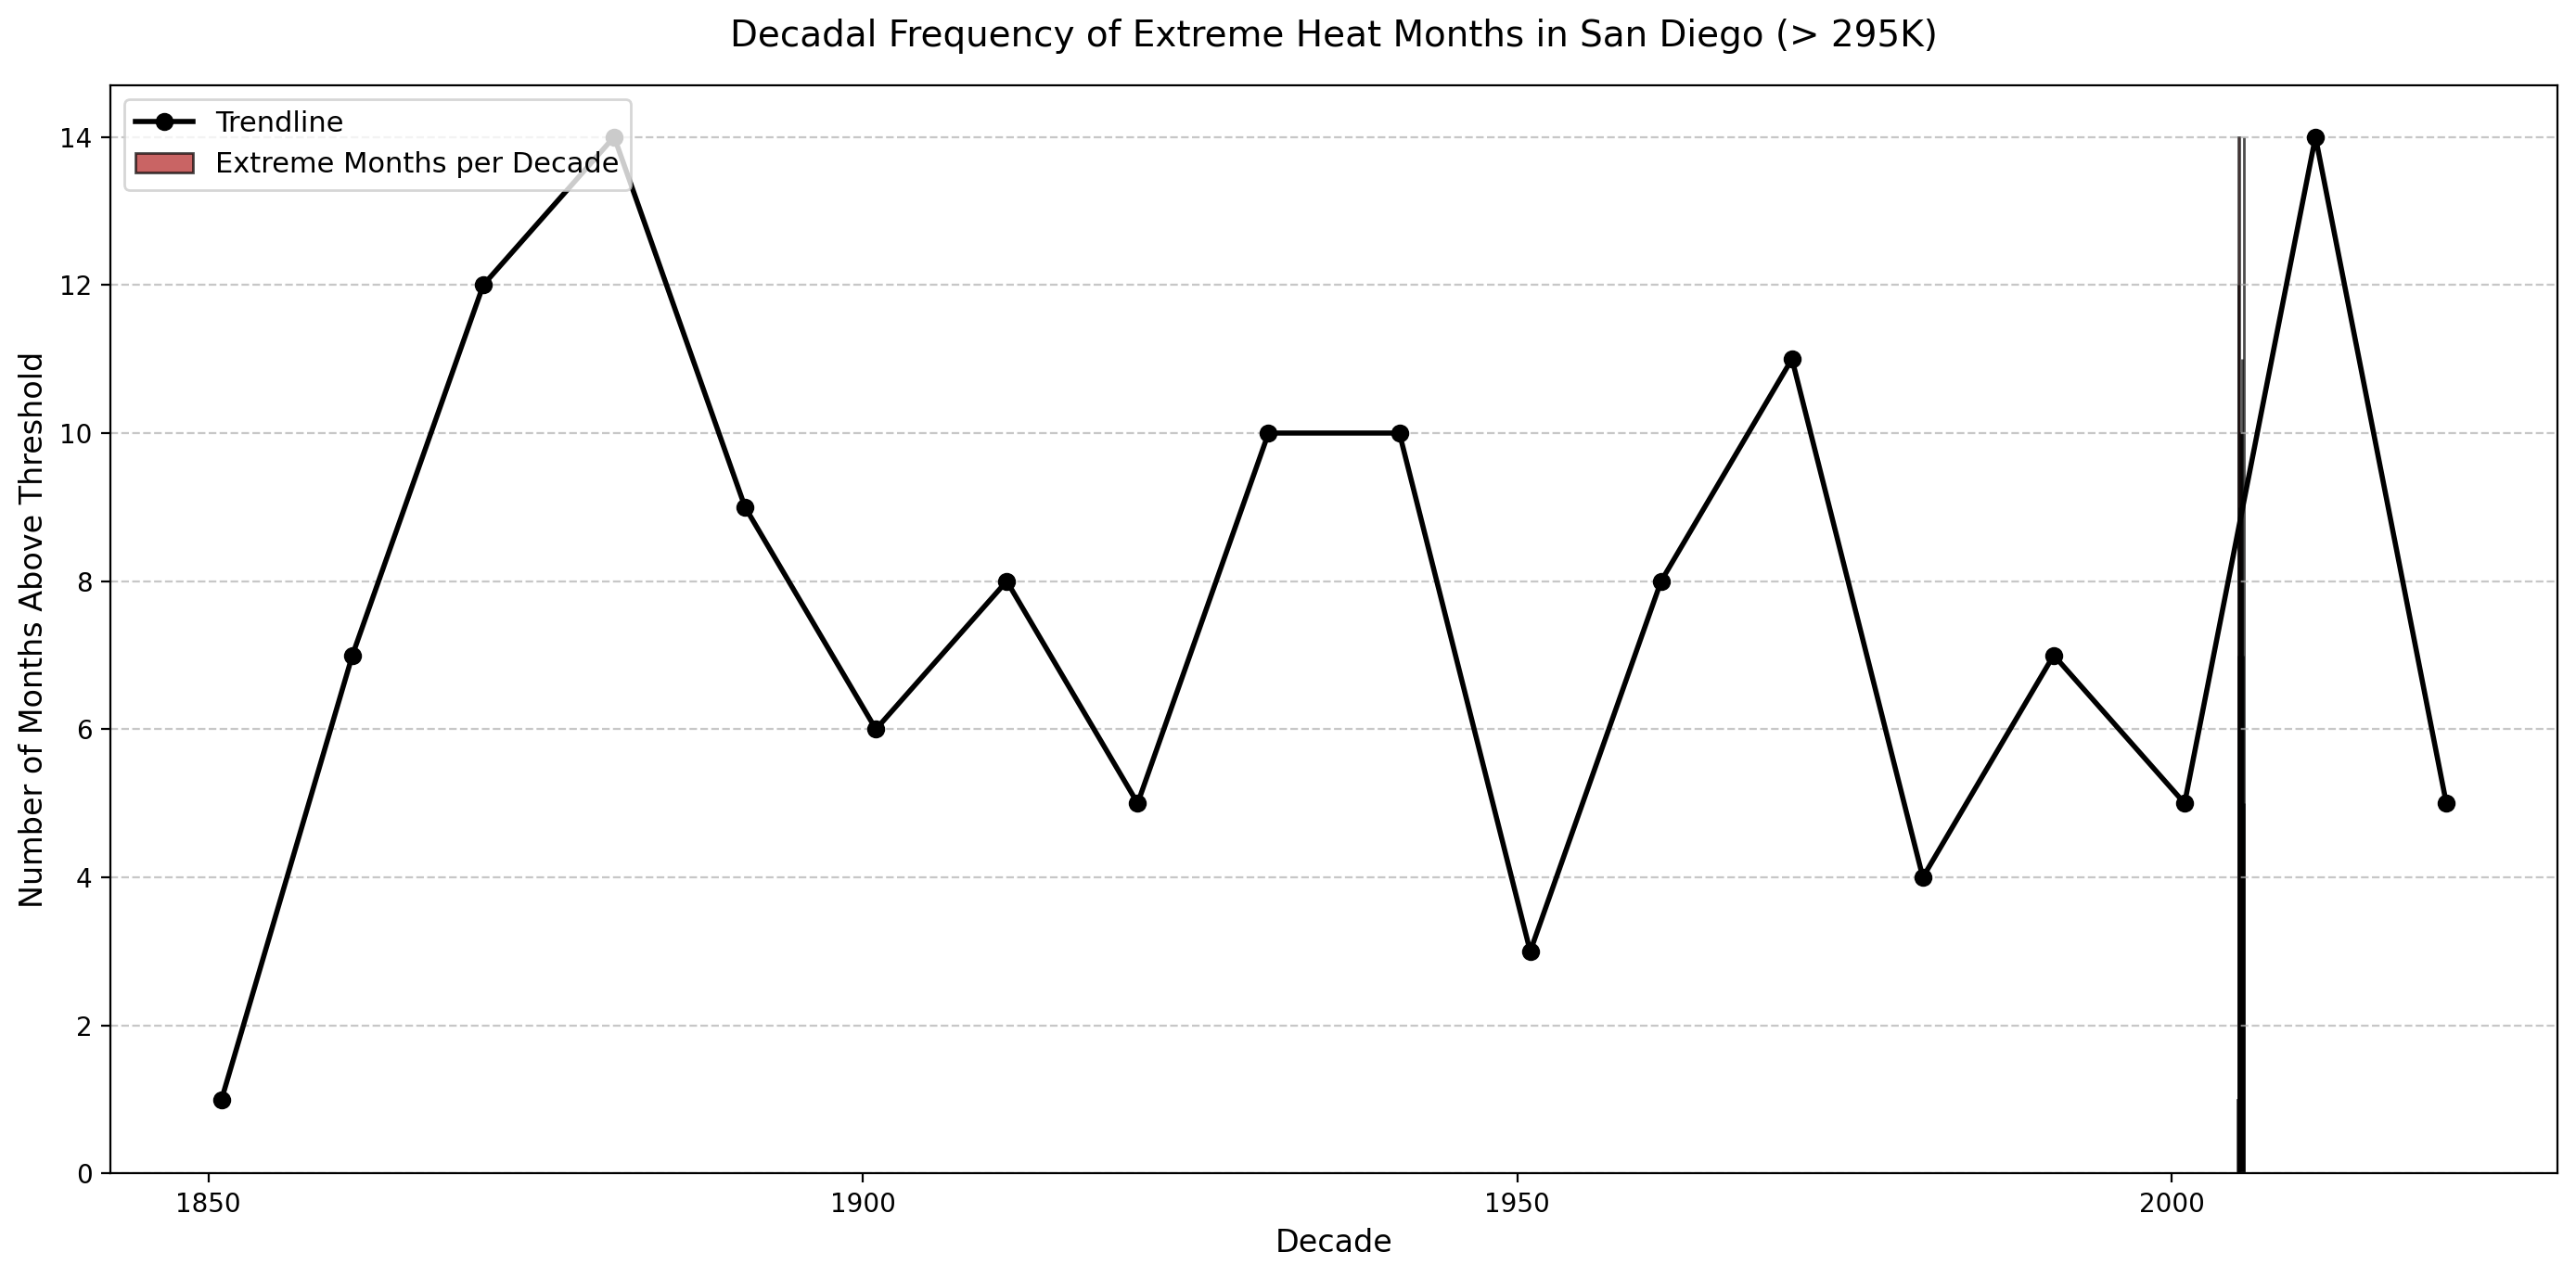

In [21]:
import matplotlib.pyplot as plt

threshold = 295 

extremes = (sd_time_series > threshold).resample(time='10YE').sum()

fig, ax = plt.subplots(figsize=(14, 7))

ax.bar(extremes.time.dt.year, extremes.values, width=8, color='firebrick', alpha=0.7, edgecolor='black', label='Extreme Months per Decade')
extremes.plot.line(ax=ax, color='black', marker='o', linewidth=2, markersize=6, label='Trendline')

ax.set_title(f'Decadal Frequency of Extreme Heat Months in San Diego (> {threshold}K)', fontsize=14, pad=15)
ax.set_ylabel('Number of Months Above Threshold', fontsize=12)
ax.set_xlabel('Decade', fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.legend(loc='upper left', fontsize=11)

plt.tight_layout()
plt.show()